# View Ray Tracer Output

Load and display ray tracer images — either PGM (P5 binary) files or the
`"image"` array embedded in HDF5 field snapshots.

Set `DATA_ROOT` below to point to your ray tracer output directory.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from pathlib import Path
import re

In [2]:
# ============================================================
#  Path setup — same pattern as AJ_analysis
# ============================================================
# The ray tracer writes into output_dir (default "Data/") under
# the Aperture4 root.  Adjust this to point at your run directory.
DATA_ROOT = Path(
    "/data/RIS/cyuran/Active/giantflares/Aaron/Aperture4"
)

# ============================================================
#  PGM (P5 binary) helpers
# ============================================================
def read_pgm_p5(filepath):
    """Read a P5 (binary) PGM file → (width, height, maxval, pixels)."""
    with open(filepath, "rb") as f:
        header = f.readline().strip()
        if header != b"P5":
            raise ValueError(f"Not a P5 PGM file: {header}")
        line = f.readline()
        while line.startswith(b"#"):
            line = f.readline()
        width, height = map(int, line.split())
        maxval = int(f.readline().strip())
        dtype = np.uint8 if maxval < 256 else np.uint16
        pixels = np.frombuffer(f.read(), dtype=dtype)
        return width, height, maxval, pixels.reshape((height, width))


def find_pgm_files(data_dir, pattern="rt_image_*.pgm"):
    """Glob PGM files, sorted by embedded step number."""
    data_dir = Path(data_dir)
    return sorted(
        data_dir.glob(pattern),
        key=lambda p: int(re.search(r"(\d+)", p.stem).group()),
    )


# ============================================================
#  HDF5 snapshot helper — "image" is saved with field data
# ============================================================
def get_image_h5(filepath, dataset_name="image", base_dir=DATA_ROOT):
    """
    Read the 2-D ``image`` array from an HDF5 field snapshot.

    Parameters
    ----------
    filepath : str or Path
        Relative or absolute path, e.g. ``"Data/fld.00005.h5"``.
    dataset_name : str
        Dataset name inside the HDF5 file (default ``"image"``).
    base_dir : Path
        Prepended when *filepath* is relative.
    """
    base_dir = Path(base_dir)
    filepath = Path(filepath)
    resolved = filepath if filepath.is_absolute() else base_dir / filepath

    with h5py.File(resolved, "r") as f:
        if dataset_name not in f:
            available = sorted(f.keys())
            raise KeyError(
                f"'{dataset_name}' not found in {resolved.name}. "
                f"Available: {available}"
            )
        img = np.asarray(f[dataset_name])
        # HDF5 data is (y, x) from Fortran-ordered write; transpose to (x, y)
        print(f"✓ '{dataset_name}' from {resolved.name}  shape={img.shape}")
        return img.T


def find_image_h5(data_dir, pattern="fld.*.h5", dataset_name="image"):
    """Find HDF5 field snapshots that contain ``dataset_name``."""
    data_dir = Path(data_dir)
    files = sorted(
        data_dir.glob(pattern),
        key=lambda p: int(re.search(r"(\d+)", p.stem).group()),
    )
    valid = []
    for p in files:
        try:
            with h5py.File(p, "r") as f:
                if dataset_name in f:
                    valid.append(p)
        except Exception:
            pass
    return valid

### Discover available images

This tries the PGM directory first, then falls back to HDF5 snapshots.

In [4]:
# --- Choose your data source ---
#  PGM: the ray tracer writes Data/rt_image_*.pgm
pgm_dir = DATA_ROOT / "problems/ray_tracing/bin"
#  HDF5: the "image" array is included in fld.*.h5 snapshots
h5_dir  = DATA_ROOT / "problems/ray_tracing/bin"

use_pgm = True   # set False to read from HDF5 snapshots instead

if use_pgm:
    files = find_pgm_files(pgm_dir, "rt_image_*.pgm")
    print(f"Found {len(files)} PGM file(s) in {pgm_dir}:")
    for f in files:
        w, h, maxval, _ = read_pgm_p5(str(f))
        print(f"  {f.name}  ({w}x{h}, maxval={maxval})")
else:
    files = find_image_h5(h5_dir, "fld.*.h5", "image")
    print(f"Found {len(files)} HDF5 snapshot(s) with 'image' in {h5_dir}:")
    for f in files:
        print(f"  {f.name}")

Found 41 PGM file(s) in /data/RIS/cyuran/Active/giantflares/Aaron/Aperture4/problems/ray_tracing/bin:
  rt_image_0.pgm  (128x128, maxval=255)
  rt_image_5.pgm  (128x128, maxval=255)
  rt_image_10.pgm  (128x128, maxval=255)
  rt_image_15.pgm  (128x128, maxval=255)
  rt_image_20.pgm  (128x128, maxval=255)
  rt_image_25.pgm  (128x128, maxval=255)
  rt_image_30.pgm  (128x128, maxval=255)
  rt_image_35.pgm  (128x128, maxval=255)
  rt_image_40.pgm  (128x128, maxval=255)
  rt_image_45.pgm  (128x128, maxval=255)
  rt_image_50.pgm  (128x128, maxval=255)
  rt_image_55.pgm  (128x128, maxval=255)
  rt_image_60.pgm  (128x128, maxval=255)
  rt_image_65.pgm  (128x128, maxval=255)
  rt_image_70.pgm  (128x128, maxval=255)
  rt_image_75.pgm  (128x128, maxval=255)
  rt_image_80.pgm  (128x128, maxval=255)
  rt_image_85.pgm  (128x128, maxval=255)
  rt_image_90.pgm  (128x128, maxval=255)
  rt_image_95.pgm  (128x128, maxval=255)
  rt_image_100.pgm  (128x128, maxval=255)
  rt_image_105.pgm  (128x128, maxval=2

### View a single frame

Set `index` to choose which frame (0 = first, -1 = last).

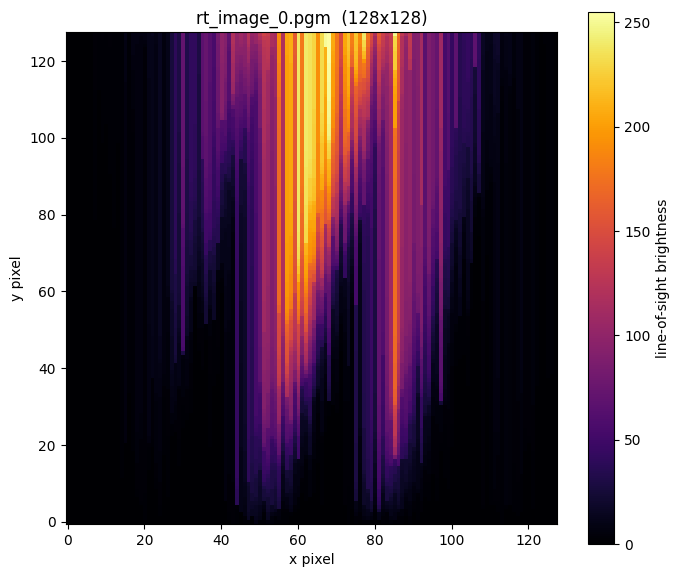

In [5]:
index = 0  # change to view different frames (0 = first, -1 = last)

if use_pgm:
    filepath = files[index]
    w, h, maxval, img = read_pgm_p5(str(filepath))
    title = f"{filepath.name}  ({w}x{h})"
else:
    filepath = files[index]
    img = get_image_h5(filepath, base_dir=".")   # files already absolute
    w, h = img.shape
    title = f"{filepath.name}  ({w}x{h})"

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(img.T if use_pgm else img, origin="lower",
               cmap="inferno", aspect="equal")
ax.set_title(title)
ax.set_xlabel("x pixel"); ax.set_ylabel("y pixel")
plt.colorbar(im, ax=ax, label="line-of-sight brightness")
plt.tight_layout()
plt.show()

### View all frames side-by-side (up to first 16)

In [ ]:
n = min(len(files), 16)
cols = min(n, 4)
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3.5 * rows))
axes = np.atleast_1d(axes).flatten()

# load all frames
imgs = []
global_max = 0
for f in files[:n]:
    if use_pgm:
        _, _, _, img = read_pgm_p5(str(f))
    else:
        img = get_image_h5(f, base_dir=".")
    imgs.append(img)
    global_max = max(global_max, img.max())
global_max = max(global_max, 1)

for i, (f, img) in enumerate(zip(files[:n], imgs)):
    im = axes[i].imshow(
        img.T if use_pgm else img,
        origin="lower", cmap="inferno", aspect="equal",
        vmin=0, vmax=global_max,
    )
    step = re.search(r"(\d+)", f.stem).group()
    axes[i].set_title(f"step {step}")
    axes[i].set_xlabel("x"); axes[i].set_ylabel("y")

for j in range(n, len(axes)):
    axes[j].set_visible(False)

if n > 1:
    fig.colorbar(im, ax=list(axes[:n]), label="brightness", shrink=0.8)
plt.tight_layout()
plt.show()